In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [4]:
transform = transforms.ToTensor()

# Add extra mirrors so MNIST download works on more networks.
datasets.MNIST.mirrors = [
    "https://storage.googleapis.com/cvdf-datasets/mnist/",
    "https://ossci-datasets.s3.amazonaws.com/mnist/",
    "https://yann.lecun.com/exdb/mnist/",
]

train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_data = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64)

  0%|          | 0/9912422 [00:00<?, ?it/s]

Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw



  0%|          | 0/28881 [00:00<?, ?it/s]

Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw



  0%|          | 0/1648877 [00:00<?, ?it/s]

Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw



  0%|          | 0/4542 [00:00<?, ?it/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



torch.Size([1, 28, 28])
5


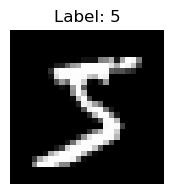

In [22]:
image, label = train_data[0]
print(image.shape)
print(label)

plt.figure(figsize=(2, 2))
plt.imshow(image.squeeze(), cmap='gray')   # squeeze() 把 [1,28,28] 变成 [28,28]
plt.title(f"Label: {label}")
plt.axis('off')   # 不显示坐标轴
plt.show()

In [6]:
class CNN(nn.Module):
    def __init__(self) -> None:
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(2), # -> (14x14)

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)   # -> (7x7)
        )
        self.fc = nn.Linear(32 * 7 * 7, 10)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x